# Extract Needed Variables from Observed Sea Level Data

This notebook performs the following steps:

1. **Load tide gauge sea level data**  
   Tide gauge data are stored as `.pkl` files, each containing a `pandas.Series` with a datetime index and a column `'SL'` representing sea level.

2. **Search and remove any outliers**  
   Search and remove outliers using a rolling time window and a threshold based on the window's median and standard deviation.
   
3. **Remove Sea Level Rise (SLR)**  
   Detrend the data by removing long-term trends using linear regression.

4. **Predict the tidal signal per tide gauge**  
   Use harmonic analysis to model the tidal component of the signal.

5. **Calculate the Non-tidal Residual**  
   Subtract the predicted tidal signal from the observed sea level to isolate residuals.

6. **Calculate the Skew-surge**  
   Estimate skew-surge values by analyzing deviations from the predicted tidal peaks.

The station metadata is provided in a `stations_info.csv` file, which contains station information such as name, longitude, and latitude.


## 1. Load data

In [17]:
import pandas as pd

# Load station info (names,lon,lat)
stations = pd.read_csv("inputs/stations_info.csv", usecols=["station", "lon", "lat"])
stations

,station,lon,lat
0,Huibertgat,6.398433,53.573748
1,Schiermonnikoog,6.202908,53.468935
2,Eemshaven,6.828392,53.448699
3,Nes,5.758907,53.429936
4,Lauwersoog,6.196952,53.408684
5,West_Terschelling,5.220026,53.363043
6,Vlieland_Haven,5.091456,53.296125
7,Harlingen,5.409342,53.175632
8,Oudeschild,4.850192,53.038833
9,Den_Helder,4.744990,52.964357


In [18]:
# Load sea level data per station in a list
SL = []
for i in range(len(stations)):
    sl_element = pd.read_pickle(f"inputs/GESLA_NLD/tide_gauge_{i}.pkl")
    # Append loaded data to lists
    SL.append(sl_element)

## 2. Search and remove any outliers

In [19]:
from utils.GESLA_extract_variables import detect_outliers_window

all_outliers = [
    detect_outliers_window(series, deviation_threshold=3, window_size_days=2)
    for series in SL
]
all_outliers

[[],
 [],
 [],
 [],
 [],
 [],
 [],
 [23055],
 [],
 [],
 [1658685],
 [1763118],
 [1317687,
  1317688,
  1317689,
  1740152,
  1740153,
  1740154,
  1740155,
  2312054,
  2312055,
  2312056,
  2312063,
  2312064],
 [1553726, 1553727, 1553728],
 [],
 []]

## 3. Remove Sea Level Rise (SLR)

In [20]:
from utils.GESLA_extract_variables import detrend_series

trends = []
detrended_SL = []

for sl_element in SL:
    detrended, trend = detrend_series(sl_element)
    trends.append(trend)
    detrended_SL.append(detrended)

## 4. Predict the tidal signal per tide gauge

In [21]:
import utide

tides = []
coefs = []

for i, detrended_series in enumerate(detrended_SL):
    detrended_series.dropna(inplace=True)
    t = detrended_series.index

    # Solve for tidal coefficients
    coef = utide.solve(
        t,
        detrended_series,
        lat=stations["lat"][i],
        method="ols",
        nodal=True,
        trend=False,
        conf_int="MC",
    )

    # Reconstruct tidal signal
    reconstruction = utide.reconstruct(t, coef)
    tide = pd.Series(reconstruction.h, index=reconstruction.t_in)

    tides.append(tide)
    coefs.append(coef)

solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ..

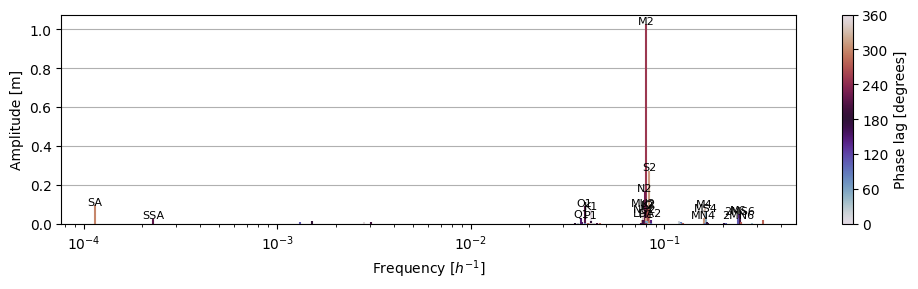

(<Figure size 1000x300 with 2 Axes>,
 <Axes: xlabel='Frequency [$h^{-1}$]', ylabel='Amplitude [m]'>)

In [22]:
from utils.GESLA_extract_variables import HarmonicAnalysis

# Usage without specifying efreq
ha = HarmonicAnalysis(coefs[0])  # first station
ha.plot_coefs()

## 5. Calculate the Non-tidal Residual

In [23]:
## NTR = detrended SL - tides

NTR = [detrended - tide for detrended, tide in zip(detrended_SL, tides)]
NTR

[1972-12-31 23:00:00   -0.115798
 1973-01-01 00:00:00   -0.143190
 1973-01-01 01:00:00   -0.134129
 1973-01-01 02:00:00   -0.087486
 1973-01-01 03:00:00   -0.038039
                          ...   
 2018-09-07 23:10:00    0.133470
 2018-09-07 23:20:00    0.134670
 2018-09-07 23:30:00    0.141399
 2018-09-07 23:40:00    0.154153
 2018-09-07 23:50:00    0.143487
 Length: 1759606, dtype: float64,
 1970-12-31 23:00:00    0.006184
 1971-01-01 00:00:00   -0.050093
 1971-01-01 01:00:00   -0.120589
 1971-01-01 02:00:00   -0.215426
 1971-01-01 03:00:00   -0.177769
                          ...   
 2018-09-07 23:10:00    0.177663
 2018-09-07 23:20:00    0.195453
 2018-09-07 23:30:00    0.211819
 2018-09-07 23:40:00    0.225941
 2018-09-07 23:50:00    0.236978
 Length: 1716065, dtype: float64,
 1978-12-29 08:00:00   -0.592475
 1978-12-29 09:00:00   -0.638412
 1978-12-29 10:00:00   -0.679678
 1978-12-29 11:00:00   -0.718835
 1978-12-29 12:00:00   -0.733895
                          ...   
 2018-09

## 6. Calculate the Skew Surge

To compute the **skew surge**, we follow these steps:

1. **Extract the predicted high water levels**  
   Use the *turning point method* (Haigh et al., 2016; Woodworth et al., 1991) to identify tidal high waters.

2. **Identify the nearest observed high water level**  
   Match each predicted high tide with the closest measured peak in the observed data.

3. **Calculate the skew surge**  
   Subtract the predicted high water from the observed high water:
   
<div align="center"><strong>Skew Surge = Observed High Water − Predicted High Water</strong></div>

In [24]:
from utils.GESLA_extract_variables import (
    extract_high_water_tides,
    find_measured_high_water,
)

high_water_tides = extract_high_water_tides(tides, min_hours_between=6)
high_water_measured = find_measured_high_water(
    detrended_SL, high_water_tides, time_window_hours=6
)

skew_surge = [
    measured - tide for measured, tide in zip(high_water_measured, high_water_tides)
]

## Save variables (optional)

In [25]:
import os

os.makedirs("outputs", exist_ok=True)

for i, (
    sl_element,
    detrended_element,
    tides_element,
    NTR_element,
    high_tide_element,
    high_meas_element,
    skew_element,
) in enumerate(
    zip(SL, detrended_SL, tides, NTR, high_water_tides, high_water_measured, skew_surge)
):
    sl_element.to_pickle(f"outputs/tide_gauge_{i}.pkl")
    detrended_element.to_pickle(f"outputs/detrended_SL_{i}.pkl")
    tides_element.to_pickle(f"outputs/tides_{i}.pkl")
    NTR_element.to_pickle(f"outputs/ntr_{i}.pkl")
    high_tide_element.to_pickle(f"outputs/high_water_tide_{i}.pkl")
    high_meas_element.to_pickle(f"outputs/high_water_measured_{i}.pkl")
    skew_element.to_pickle(f"outputs/skew_surge_{i}.pkl")